### **[A Practical Guide to Time Series Forecasting for Business](https://medium.com/data-science-collective/f257eb10c474)**

> *How to Build a Forecasting Model for Transaction Volume that Drive Business Planning*

In [1]:
!pip install -qq hijridate hijri-converter LunarCalendar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.4 MB/s eta 0:00:00


In [2]:
import sys

import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

IN_COLAB = 'google.colab' in sys.modules

np.set_printoptions(threshold=sys.maxsize, suppress=True, precision=3)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.precision', 3)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

%autosave 10

Autosaving every 10 seconds


#### **Visual Inspection**

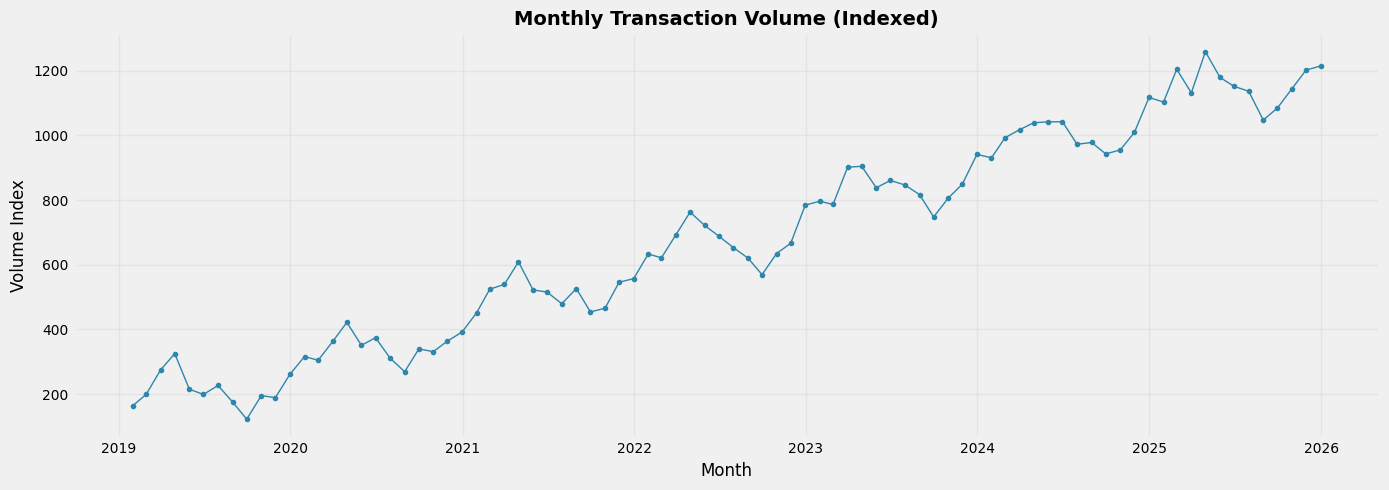

In [3]:
# ============================================
# MOCK DATA: Similar patterns, synthetic values
# Safe to share - no real business data
# ============================================
np.random.seed(42)
dates = pd.date_range('2019-01-01', '2025-12-31', freq='M')

# Create realistic patterns
n = len(dates)
trend = np.linspace(100, 1200, n)  # Growth trend
seasonality = 80 * np.sin(np.arange(n) * 2 * np.pi / 12)  # Yearly cycle
# Add festival spikes (CNY ~Feb, Raya ~Apr, Deepavali ~Nov, Year-end ~Dec)
festivals = np.zeros(n)
for i, date in enumerate(dates):
  if date.month in [1, 2]:  # CNY period
    festivals[i] = 50
  elif date.month in [3, 4]:  # Raya period
    festivals[i] = 60
  elif date.month in [10, 11]:  # Deepavali
    festivals[i] = 40
  elif date.month == 12:  # Year-end
    festivals[i] = 70

noise = np.random.normal(0, 30, n)
volume = trend + seasonality + festivals + noise

df = pd.DataFrame({'date': dates, 'volume': volume})

# Plot
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['volume'], '-o', markersize=3, color='#2E86AB', linewidth=1)
plt.title('Monthly Transaction Volume (Indexed)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Volume Index')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### **Seasonal Plot (Year-over-Year Comparison)**

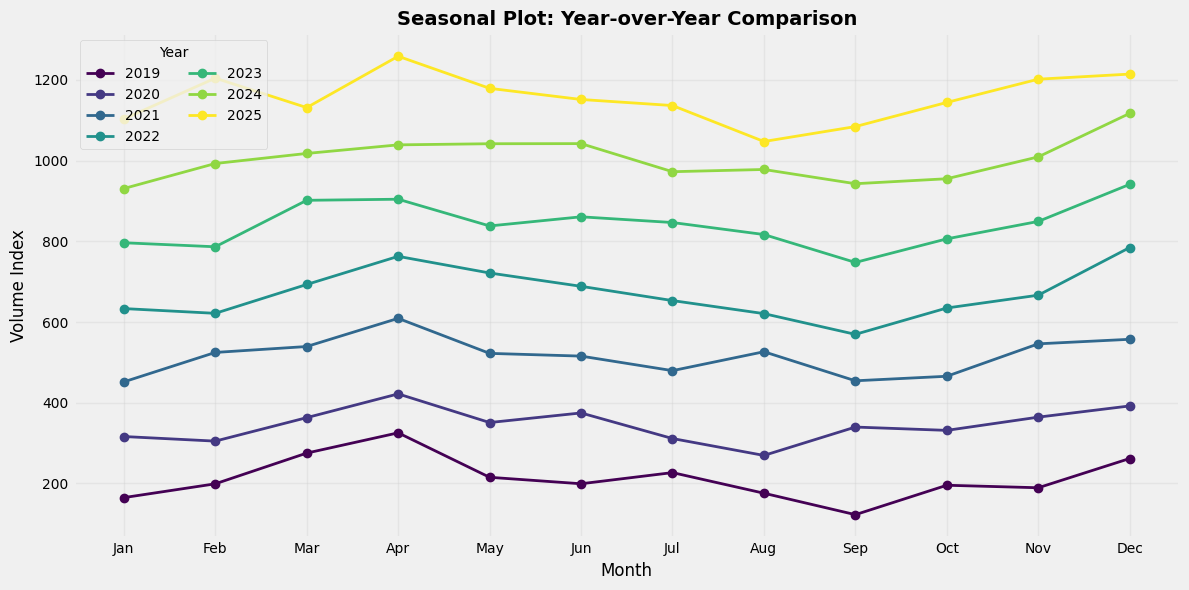

In [4]:
# Create seasonal plot with mock data
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(df['year'].unique())))

for i, year in enumerate(sorted(df['year'].unique())):
  year_data = df[df['year'] == year]
  ax.plot(year_data['month'], year_data['volume'],
          marker='o', label=str(year), linewidth=2, color=colors[i])

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Volume Index', fontsize=12)
ax.set_title('Seasonal Plot: Year-over-Year Comparison', fontsize=14, fontweight='bold')
ax.legend(title='Year', loc='upper left', ncol=2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### **Seasonal Decomposition**

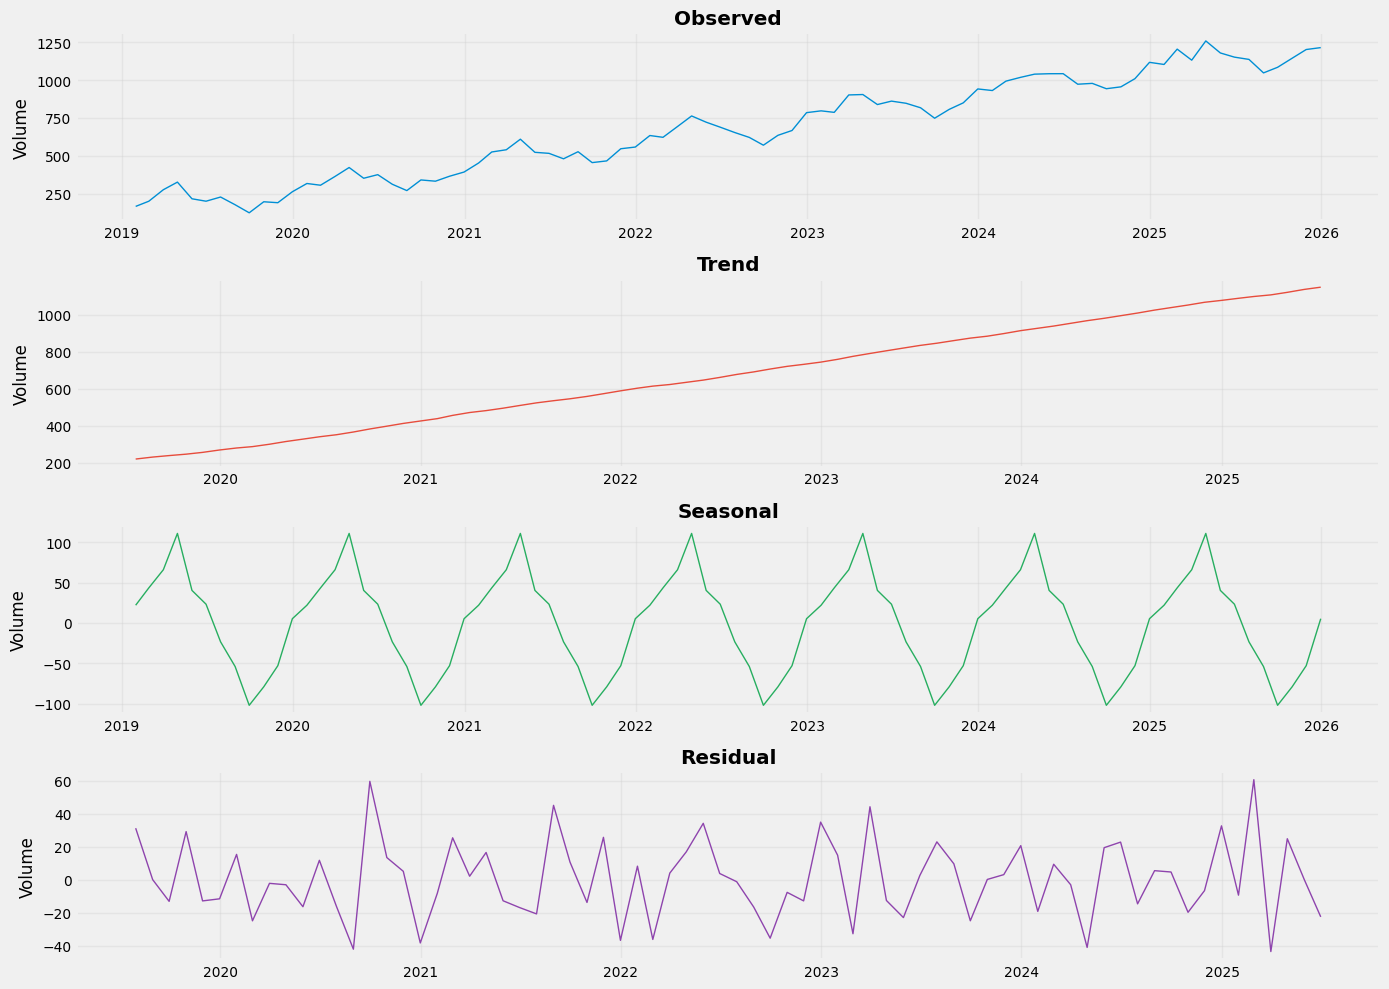

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the series
decomposition = seasonal_decompose(
  df.set_index('date')['volume'],
  model='additive',
  period=12  # Monthly data with yearly seasonality
)

# Plot components
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(decomposition.observed, linewidth=1)
axes[0].set_title('Observed', fontweight='bold')
axes[0].set_ylabel('Volume')

axes[1].plot(decomposition.trend, linewidth=1, color='#E74C3C')
axes[1].set_title('Trend', fontweight='bold')
axes[1].set_ylabel('Volume')

axes[2].plot(decomposition.seasonal, linewidth=1, color='#27AE60')
axes[2].set_title('Seasonal', fontweight='bold')
axes[2].set_ylabel('Volume')

axes[3].plot(decomposition.resid, linewidth=1, color='#8E44AD')
axes[3].set_title('Residual', fontweight='bold')
axes[3].set_ylabel('Volume')

for ax in axes:
  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **Calculating Strength Scores**

In [6]:
def calculate_strength_scores(decomposition):
  """
  Calculate trend and seasonality strength using
  Hyndman & Athanasopoulos formula from "Forecasting: Principles and Practice"
  """
  # Extract components
  trend = decomposition.trend.dropna()
  seasonal = decomposition.seasonal
  resid = decomposition.resid.dropna()

  # Align indices
  common_idx = trend.index.intersection(resid.index)
  trend = trend.loc[common_idx]
  resid = resid.loc[common_idx]
  seasonal_aligned = seasonal.loc[common_idx]

  # Calculate variance
  var_resid = np.var(resid)
  var_trend_resid = np.var(trend + resid)
  var_seasonal_resid = np.var(seasonal_aligned + resid)

  # Strength scores (bounded 0-1)
  trend_strength = max(0, 1 - var_resid / var_trend_resid)
  seasonality_strength = max(0, 1 - var_resid / var_seasonal_resid)

  return trend_strength, seasonality_strength

trend_str, seasonal_str = calculate_strength_scores(decomposition)
print(f"Trend Strength:       {trend_str:.1%}")
print(f"Seasonality Strength: {seasonal_str:.1%}")

Trend Strength:       99.3%
Seasonality Strength: 86.8%


#### **ACF and PACF Analysis**

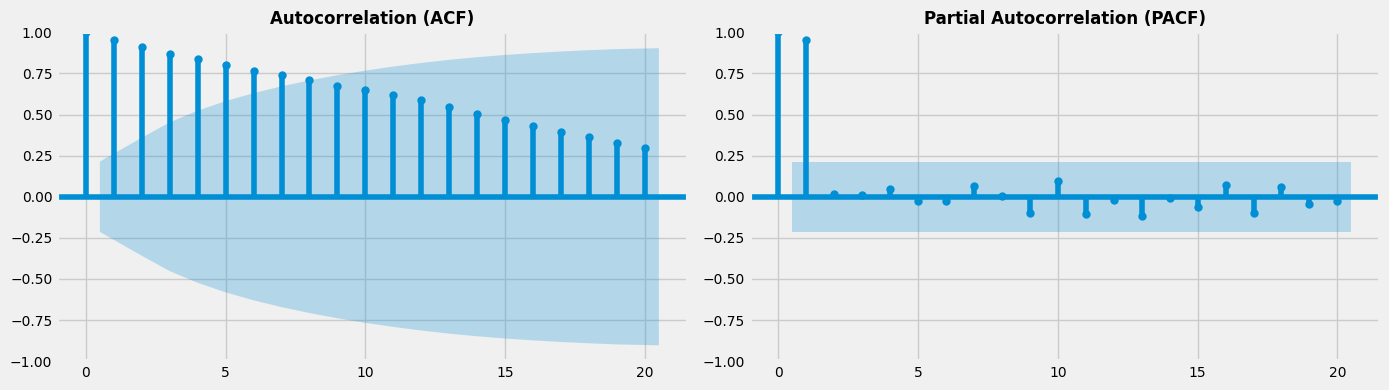

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['volume'], lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)', fontsize=12, fontweight='bold')

plot_pacf(df['volume'], lags=20, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (PACF)', fontsize=12, fontweight='bold')

plt.tight_layout()
if not IN_COLAB:
  plt.savefig('05_acf_pacf.png', dpi=150)
plt.show()

#### **Stationarity Testing (ADF Test)**

In [8]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=''):
  result = adfuller(series.dropna())
  print(f"=== ADF Test: {name} ===")
  print(f"Test Statistic: {result[0]:.4f}")
  print(f"P-Value: {result[1]:.4f}")
  print(f"Stationary: {'Yes' if result[1] < 0.05 else 'No (has trend)'}")
  print()
  return result

is_stationary = adf_test(df['volume'], '(Raw Series)')

=== ADF Test: (Raw Series) ===
Test Statistic: 0.6796
P-Value: 0.9894
Stationary: No (has trend)



#### **Prophet: Automatic Feature Learning**

In [9]:
from prophet import Prophet

# Prophet requires minimal preprocessing
prophet_df = df[['date', 'volume']].rename(columns={'date': 'ds', 'volume': 'y'})

model = Prophet(
  yearly_seasonality=True,
  weekly_seasonality=False,
  changepoint_prior_scale=0.05  # Regularization
)

# Add country holidays - Prophet handles festival effects automatically
model.add_country_holidays(country_name='MY')  # change to based on your contry where it relevant to your business

model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds
444,2026-12-27
445,2026-12-28
446,2026-12-29
447,2026-12-30
448,2026-12-31


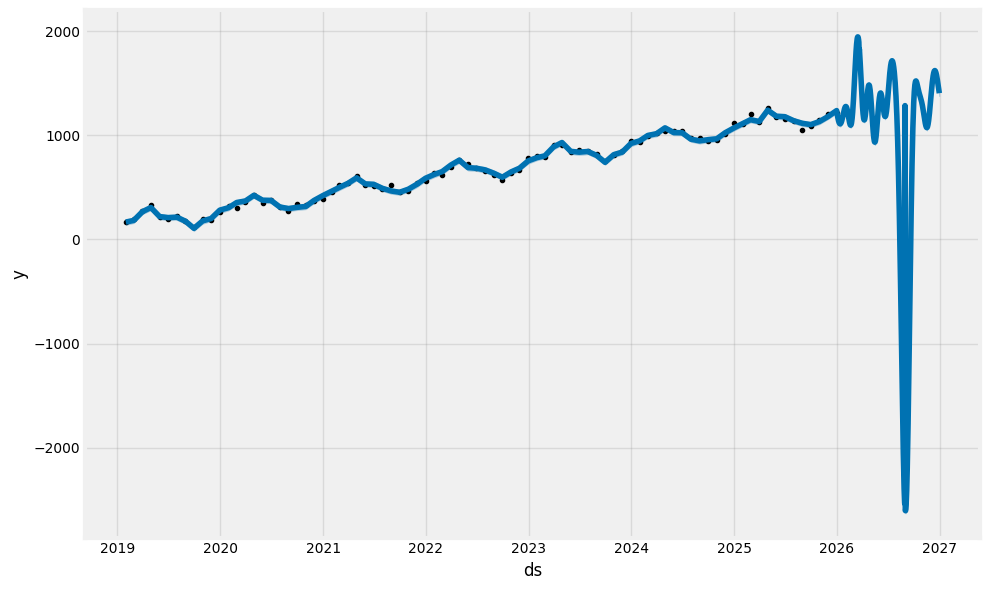

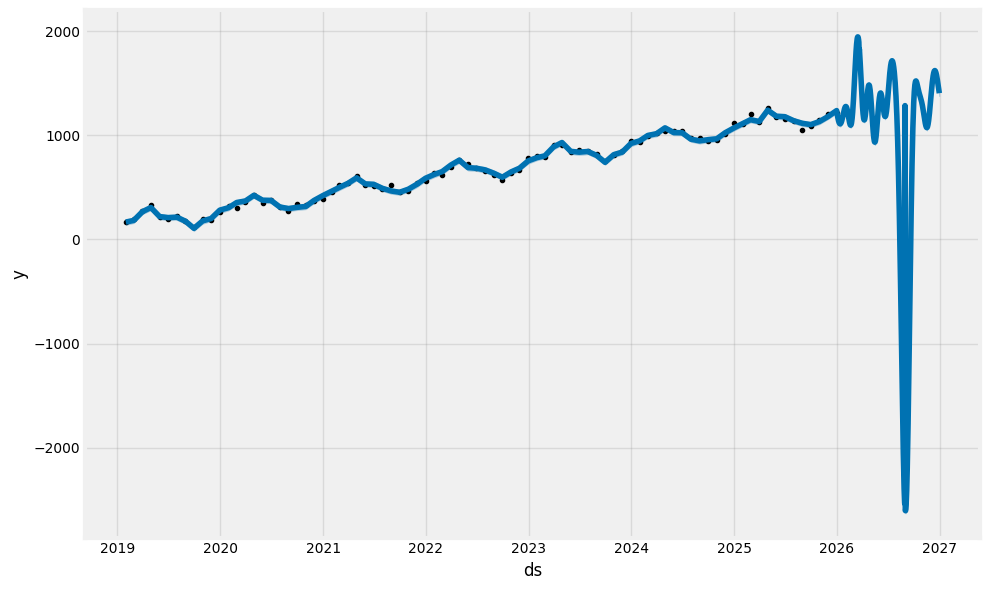

In [10]:
future = model.make_future_dataframe(periods=365)

display(future.tail())

forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

model.plot(forecast)

#### **Festival Date Calculation (Domain-Specific Feature Engineering)**

In [11]:
from hijri_converter import Hijri
from lunarcalendar import Converter, Lunar

def get_cny_month(year):
  """
  Chinese New Year follows the lunar calendar.
  Falls on 1st day of 1st lunar month.
  Returns Gregorian month (1 or 2).
  """
  lunar_ny = Lunar(year, 1, 1)
  solar = Converter.Lunar2Solar(lunar_ny)
  return solar.month

def get_raya_month(year):
  """
  Hari Raya Aidilfitri follows the Hijri (Islamic) calendar.
  Falls on 1st Syawal (10th Hijri month).
  Shifts ~11 days earlier each Gregorian year.
  Returns Gregorian month (typically 3-6).
  """
  for hijri_year in range(1440, 1450):
      raya = Hijri(hijri_year, 10, 1).to_gregorian()
      if raya.year == year:
          return raya.month
  return None

def get_deepavali_month(year):
  """
  Deepavali follows the Hindu lunar calendar.
  Falls in October or November.
  """
  # Lookup table (can be calculated more precisely)
  deepavali_dates = {
    2019: 10, 2020: 11, 2021: 11, 2022: 10,
    2023: 11, 2024: 11, 2025: 10, 2026: 11
  }
  return deepavali_dates.get(year, 11)

# Helper functions for df.apply as per the original code's intention
def is_cny_month(date_obj):
  cny_month_num = get_cny_month(date_obj.year)
  return 1 if date_obj.month == cny_month_num else 0

def is_raya_month(date_obj):
  raya_month_num = get_raya_month(date_obj.year)
  return 1 if date_obj.month == raya_month_num else 0

def is_deepavali_month(date_obj):
  deepavali_month_num = get_deepavali_month(date_obj.year)
  return 1 if date_obj.month == deepavali_month_num else 0

def create_festival_features(df):
  """
  Create binary flags for festival months
  """
  df = df.copy()
  df['year'] = df['date'].dt.year
  df['month'] = df['date'].dt.month

  # Calculate festival months
  df['cny_month'] = df['year'].apply(get_cny_month)
  df['raya_month'] = df['year'].apply(get_raya_month)
  df['deepavali_month'] = df['year'].apply(get_deepavali_month)

  # Create binary flags
  df['has_cny'] = (df['month'] == df['cny_month']).astype(int)
  df['has_raya'] = (df['month'] == df['raya_month']).astype(int)
  df['has_deepavali'] = (df['month'] == df['deepavali_month']).astype(int)
  df['is_year_end'] = (df['month'] == 12).astype(int)

  # Clean up
  df = df.drop(['cny_month', 'raya_month', 'deepavali_month'], axis=1)

  return df

#### **Ridge Regression: Manual Feature Engineering Required**

In [12]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Based on PACF: AR(1) pattern → add lag-1 feature
df['prev_month_volume'] = df['volume'].shift(1)

# Based on seasonal plot: YoY patterns
df['prev_year_volume'] = df['volume'].shift(12)

# Calendar features
df['month'] = df['date'].dt.month

# Festival features (change to based on your domain knowledge on the business and dataset)
df['has_cny'] = df.apply(lambda x: is_cny_month(x['date']), axis=1)
df['has_raya'] = df.apply(lambda x: is_raya_month(x['date']), axis=1)
df['has_deepavali'] = df.apply(lambda x: is_deepavali_month(x['date']), axis=1)
df['is_year_end'] = (df['month'] == 12).astype(int)

display(df.sample(10))

# Prepare features
feature_cols = ['prev_month_volume', 'prev_year_volume', 'month',
                'has_cny', 'has_raya', 'has_deepavali', 'is_year_end']

X = df[feature_cols].dropna()
y = df.loc[X.index, 'volume']

# Scale and fit
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y)

,date,volume,year,month,prev_month_volume,prev_year_volume,has_cny,has_raya,has_deepavali,is_year_end
7,2019-08-31,175.79,2019,8,226.89,NaN,0,0,0,0
62,2024-03-31,1017.78,2024,3,992.86,901.66,0,0,0,0
43,2022-08-31,620.85,2022,8,653.16,526.41,0,0,0,0
54,2023-07-31,846.59,2023,7,860.76,653.16,0,0,0,0
36,2022-01-31,633.37,2022,1,557.23,451.74,0,0,0,0
53,2023-06-30,860.76,2023,6,838.13,688.51,0,0,0,0
69,2024-10-31,955.10,2024,10,942.77,806.15,0,0,0,0
37,2022-02-28,621.57,2022,2,633.37,524.65,1,0,0,0
76,2025-05-31,1179.12,2025,5,1258.63,1041.85,0,0,0,0
74,2025-03-31,1131.41,2025,3,1204.41,1017.78,0,1,0,0


Ridge()

#### **Train/Test Split Strategy**

In [13]:
train = df[df['date'] < '2025-01-01']  # 2019-2024 (72 months)
test = df[df['date'] >= '2025-01-01']   # 2025 (12 months)

print(f"Train: {len(train)} months")
print(f"Test:  {len(test)} months")

Train: 72 months
Test:  12 months


#### **Evaluation Metrics**

In [14]:
from sklearn.metrics import mean_absolute_percentage_error

def evaluate_forecast(actual, predicted, model_name):
  """Comprehensive forecast evaluation"""

  mape = mean_absolute_percentage_error(actual, predicted) * 100
  rmse = np.sqrt(np.mean((actual - predicted) ** 2))
  mae = np.mean(np.abs(actual - predicted))

  # Directional accuracy
  actual_dir = np.sign(np.diff(actual))
  pred_dir = np.sign(np.diff(predicted))
  dir_acc = np.mean(actual_dir == pred_dir) * 100

  print(f"\n{model_name}")
  print("=" * 40)
  print(f"MAPE:                 {mape:.2f}%")
  print(f"RMSE:                 {rmse:,.0f}")
  print(f"Directional Accuracy: {dir_acc:.1f}%")

  return mape, dir_acc

#### **Rolling Forecast Strategy**

In [15]:
def rolling_forecast_production():
  """
  Production rolling forecast workflow
  Run this at the beginning of each month
  """

  # Step 1: Get latest actuals (previous month just closed)
  latest_data = get_actual_transactions_to_date()

  # Step 2: Retrain model with all available actuals
  model = Prophet(yearly_seasonality=True)
  model.add_country_holidays(country_name='MY')
  model.fit(latest_data)

  # Step 3: Predict ONLY next month
  future = model.make_future_dataframe(periods=1, freq='M')
  forecast = model.predict(future)

  next_month_prediction = forecast.iloc[-1]['yhat']
  confidence_lower = forecast.iloc[-1]['yhat_lower']
  confidence_upper = forecast.iloc[-1]['yhat_upper']

  # Step 4: Store prediction for later comparison
  save_prediction(
    month=next_month,
    predicted=next_month_prediction,
    confidence_interval=(confidence_lower, confidence_upper)
  )

  return next_month_prediction

# Schedule this to run on the 1st of every month
# After month closes: compare actual vs predicted, log accuracy